In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

Create a dataset

In [3]:
data = {
    "Area" : [2600,3000,3200,3600,4000],
    "Price" : [550000, 565000,610000,680000,725000]
}

df = pd.DataFrame(data)
df

,Area,Price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


Plot the original data


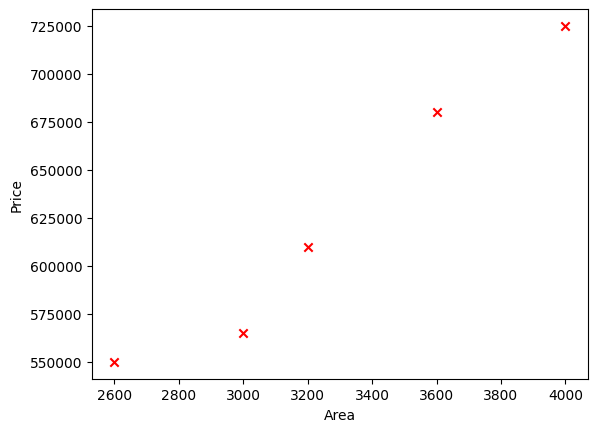

In [4]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df.Area,df.Price, color = 'red', marker='x')

Train Test Split

Coefficient: 128.27102803738316
Intercept: 211542.05607476638
MAE: 31355.140186915873
MSE: 983144816.1411468
R2 Score: nan


c:\Users\rites\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


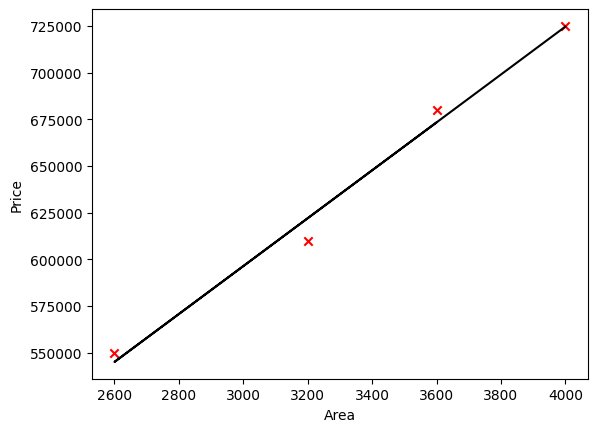

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

x = df[["Area"]]
y = df["Price"]

X_train, X_test, y_train , y_test = train_test_split(
    x,y, test_size=0.2 , random_state=42
)

reg = linear_model.LinearRegression()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)


# Print model parameters
print("Coefficient:", reg.coef_[0])
print("Intercept:", reg.intercept_)

# Evaluation on test data
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(X_train, y_train ,color = "red", marker="x")
plt.plot(X_train, reg.predict(X_train) ,color = "black")

train and predict the data

In [15]:
reg = linear_model.LinearRegression()
reg.fit(df[["Area"]], df.Price)
print("Coefficient:", reg.coef_[0])
print("Intercept:", reg.intercept_)

Coefficient: 135.78767123287673
Intercept: 180616.43835616432


In [19]:
reg.predict(pd.DataFrame({"Area" : [2500]}))

array([520085.61643836])

Check metrics // Performance 

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

y_predict = reg.predict(df[["Area"]])
print("MAE", mean_absolute_error(df["Price"],y_predict))
print("MSE", mean_squared_error(df["Price"],y_predict))
print("r2_score", r2_score(df["Price"],y_predict))


MAE 11246.57534246575
MSE 186815068.4931509
r2_score 0.9584301138199486


Plot Predicted Data (Price)

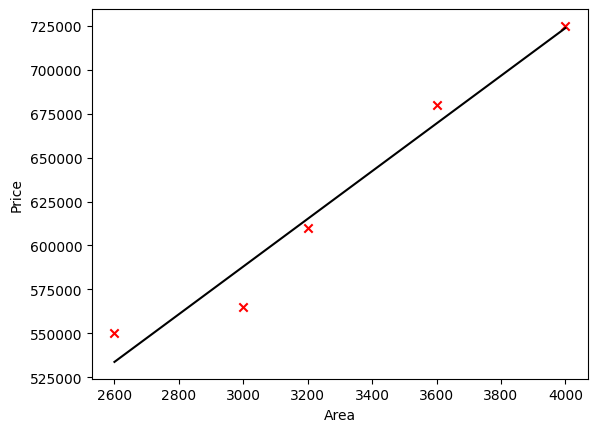

In [7]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(df.Area,df.Price,color = "red", marker="x")
plt.plot(df.Area, reg.predict(df[["Area"]]),color = "black")


New Data

In [8]:
predict_data = {
    "Area" : [1000,1200,1500,2000,2400,2600,3000]
}

pdf = pd.DataFrame(predict_data)
pdf.head(3)

,Area
0,1000
1,1200
2,1500


In [9]:
predicted_data = np.round(reg.predict(pdf)).astype(int)

In [10]:
pdf["Price"] = predicted_data
pdf

,Area,Price
0,1000,316404
1,1200,343562
2,1500,384298
3,2000,452192
4,2400,506507
5,2600,533664
6,3000,587979


New Data Plot

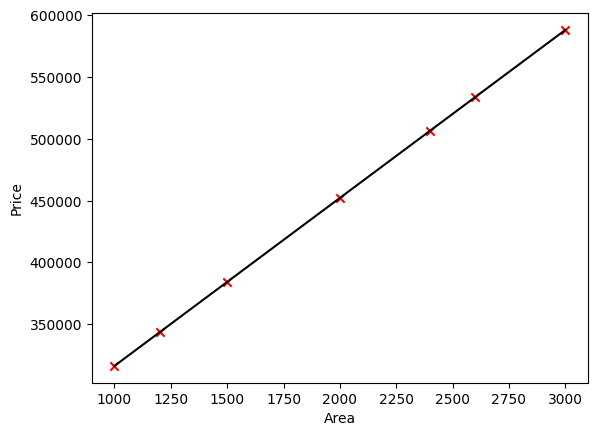

In [11]:
plt.xlabel("Area")
plt.ylabel("Price")
plt.scatter(pdf.Area,pdf.Price,color = "red", marker="x")
plt.plot(pdf.Area, reg.predict(pdf[["Area"]]),color = "black")


In [12]:
pdf.to_csv("predicted_data.csv",index = False)